In [38]:
IDENTIFY_SYSTEM_PROMPT = """
你是一名市场研究分析师。请列出该公司的 5 个主要竞争对手，并以英文逗号分隔的列表形式输出，不要输出任何其他内容。
"""

IDENTYFY_USER_PROMPT = """
公司：{company}
所属行业：{industry}

请列出 5 个主要竞争对手：

"""

In [ ]:
ANALYZE_SYSTEM_PROMPT = """
请用约 100 字对竞争对手进行简洁分析，内容包括：
- 主要产品
- 2 项核心优势
- 2 项主要劣势
- 定价模式
- 目标市场

"""

ANALYZE_USER_PROMPT = """
请分析 {competitor} 与 {company} 在 {industry} 行业中的竞争情况：
"""

In [40]:
REPORT_SYSTEM_PROMPT = """
你是一位战略咨询顾问。请为 {company} 编写一份竞争分析报告，内容包括：

1. 执行摘要（Executive Summary）
   - 用 3 句话概括整体竞争态势和核心结论。

2. 竞争格局分析表（Competitive Landscape）
   - 以表格形式展示主要竞争对手，包括以下信息：
     - 公司名称
     - 核心优势
     - 主要劣势
     - 产品或服务价格

3. 市场空白与机会（Market Gaps & Opportunities）
   - 总结 3 个值得关注的市场空白或潜在发展机会。

4. 针对 {company} 的战略建议（Strategic Recommendations）
   - 提出 5 项可执行的战略行动建议，帮助提升竞争优势。

5. 竞争威胁评估（Threat Assessment）
   - 对每个主要竞争对手的威胁程度进行评估，并标注为：
     - 高（High）
     - 中（Medium）
     - 低（Low）
"""

REPORT_USER_PROMPT = """
公司：{company}
所属行业：{industry}

竞争对手分析如下：

{analyses_text}
"""

In [41]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages

class AnalysisState(TypedDict):
    messages: Annotated[list, add_messages]
    company: str
    industry: str
    competitors: list[str]
    competitor_analyses: dict[str, str]
    final_report: str

In [42]:
from dotenv import load_dotenv

load_dotenv()

import os

model = os.getenv('MODEL_NAME', '')

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=model, temperature=0.2, extra_body={'enable_thinking': False})

In [43]:
from typing import cast
from langchain_core.messages import SystemMessage, HumanMessage


def identify_competitors(state: AnalysisState) -> AnalysisState:
    message = [
        SystemMessage(content=IDENTIFY_SYSTEM_PROMPT),
        HumanMessage(content=IDENTYFY_USER_PROMPT.format(company=state['company'], industry=state['industry']))
    ]
    response = llm.invoke(message)

    competitors = [c.strip() for c in cast(str, response.content).split(",")][:5]

    return { 'competitors': competitors, 'messages': [response] }

In [44]:
def analyze_competitor(state: AnalysisState) -> AnalysisState:
    analyses = {}
    messages = []
    
    for competitor in state['competitors']:
        message = [
            SystemMessage(content=ANALYZE_SYSTEM_PROMPT),
            HumanMessage(content=ANALYZE_USER_PROMPT.format(company=state['company'], competitor=competitor, industry=state['industry']))
        ]
        response = llm.invoke(message)
        analyses[competitor] = cast(str, response.content)
        messages.append(response)

    return { 'competitor_analyses': analyses, 'messages': messages }

In [45]:
def generate_report(state: AnalysisState) -> AnalysisState:
    analyses_text = "\n\n".join(f"**{name}:**\n{analysis}" for name, analysis in state["competitor_analyses"].items())

    message = [
        SystemMessage(content=REPORT_SYSTEM_PROMPT.format(company=state['company'])),
        HumanMessage(content=REPORT_USER_PROMPT.format(company=state['company'], industry=state['industry'], analyses_text=analyses_text))
    ]

    response = llm.invoke(message)

    return { 'final_report': response.content, 'messages': [response] }




In [46]:
from langgraph.graph import START, END, StateGraph
from IPython.display import display, Image

def build_graph():
    graph = StateGraph(AnalysisState)
    
    graph.add_node('identify', identify_competitors)
    graph.add_node('analyze', analyze_competitor)
    graph.add_node('report', generate_report)

    graph.add_edge(START, 'identify')
    graph.add_edge('identify', 'analyze')
    graph.add_edge('analyze', 'report')
    graph.add_edge('report', END)

    agent = graph.compile()

    display(Image(agent.get_graph().draw_mermaid_png()))

    return agent



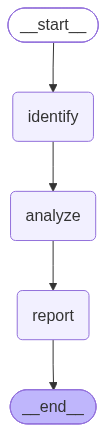

In [47]:
agent = build_graph()

In [49]:
from langchain_core.messages import BaseMessage


input_state: AnalysisState = {'company': '腾讯', 'industry': 'AI大模型', 'messages': [], 'competitors': [], 'competitor_analyses': {}, 'final_report': ''}

response = agent.stream(input=input_state, stream_mode="messages")

last_node = None

for chunk in response:
    msg, metadata = chunk

    if not isinstance(msg, BaseMessage):
        continue
    
    node = cast(dict, metadata).get("langgraph_node")

    # 节点发生变化，先换行
    if node != last_node:
        if last_node is not None:
            print("\n")   # 上一个节点结束，换行
        print(f"\n[{node}]")
        last_node = node

    if msg.content:
        print(msg.content, end="", flush=True)


[identify]
Alibaba, Baidu, ByteDance, Huawei, Tencent


[analyze]
主要产品为通义千问与混元大模型。核心优势在于阿里强大的云计算基础设施及腾讯深厚的社交生态连接能力。主要劣势是两者在垂直行业落地深度不及初创公司，且内部业务协同效率有待提升。定价模式采用基础免费加API按量计费。目标市场聚焦企业级B端服务及C端应用集成。百度主打文心一言，腾讯依托混元大模型。百度优势在于技术积累深、生态闭环强；劣势是商业化落地慢、移动端入口弱。腾讯优势为社交场景广、资金雄厚；劣势是AI起步稍晚、独立品牌认知度低。两者均采用基础免费+企业定制收费模式，主要面向B端企业及C端大众用户市场。主要产品为字节“豆包”与腾讯“混元”。优势：字节拥有海量数据与推荐算法，腾讯具备微信生态及企业级服务。劣势：字节缺乏社交闭环，腾讯C端创新稍弱。定价多采用免费+API按量计费。目标市场涵盖个人用户、开发者及政企客户，争夺B端落地与C端入口。华为主打盘古大模型，腾讯聚焦混元。华为优势在于软硬协同与行业落地，劣势在生态开放度及C端应用；腾讯优势为社交场景与算力资源，劣势在底层硬件自主性及垂直深度。两者均采用“基础模型免费+API/私有化部署收费”模式。目标市场涵盖政企数字化、云计算及互联网增值服务领域。腾讯主要推出混元大模型。核心优势在于微信生态闭环及海量数据，劣势是开源社区活跃度低且垂直行业落地稍慢。采用API调用与私有化部署混合定价。目标市场聚焦企业级应用、游戏开发及泛娱乐场景，旨在通过C端流量赋能B端智能化转型，构建差异化竞争壁垒。


[report]
# 腾讯 AI 大模型竞争分析报告

## 1. 执行摘要（Executive Summary）
腾讯凭借微信生态闭环与海量数据优势，在 C 端应用集成与企业级服务中占据独特地位，但面临百度、阿里及字节在技术品牌认知与垂直落地速度上的激烈挑战。当前市场竞争已从单纯的技术比拼转向“场景+算力+生态”的综合较量，腾讯需解决开源社区活跃度低及独立 AI 品牌认知度不足的问题以巩固壁垒。未来胜负关键在于能否将社交流量高效转化为 B 端智能化转型动力，并在游戏、泛娱乐等核心场景中实现 AI 的深度原生融合。

## 2. 竞争格局分析表（Competitive Landscape）

| 公司名称